Car Price Prediction

Importing Dependencies

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

Data Collection

In [235]:
car_data = pd.read_csv("CAR DETAILS FROM CAR DEKHO (1).csv")

In [236]:
car_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [237]:
car_data.shape

(4340, 8)

Eliminating extreme price outliers

In [238]:
q_high = car_data['selling_price'].quantile(0.98)
car_data = car_data[car_data['selling_price'] < q_high]

Data Analysis

In [239]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4253 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4253 non-null   object
 1   year           4253 non-null   int64 
 2   selling_price  4253 non-null   int64 
 3   km_driven      4253 non-null   int64 
 4   fuel           4253 non-null   object
 5   seller_type    4253 non-null   object
 6   transmission   4253 non-null   object
 7   owner          4253 non-null   object
dtypes: int64(3), object(5)
memory usage: 299.0+ KB


In [240]:
car_data.describe()

,year,selling_price,km_driven
count,4253.000000,4.253000e+03,4253.000000
mean,2013.007994,4.409096e+05,66858.730308
std,4.208571,3.384788e+05,46781.017025
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.000000e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,2.490000e+06,806599.000000


Checking for Null values

In [241]:
car_data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Encoding categorical data ( One Hot Encoding )

Changing brand column into the name column

In [242]:
car_data_cleaned = car_data.copy()
car_data_cleaned["brand"] = car_data_cleaned["name"].apply(lambda x: x.split(" ")[0])


Calculating the age and storing it in the car_age column

In [243]:
car_data_cleaned["car_age"] = 2026 - car_data_cleaned["year"]

Dropping columns name and year

In [244]:
car_data_cleaned = car_data_cleaned.drop(columns=["name","year"] ,axis=1)

Encoding of categorical data

In [245]:
car_data_encoded = pd.get_dummies(columns=["fuel","seller_type","transmission","owner","brand"],drop_first=True ,data=car_data_cleaned ,dtype=int )

In [246]:
car_data_encoded.head(10)

,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,60000,70000,19,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,135000,50000,19,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,600000,100000,14,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,250000,46000,9,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,450000,141000,12,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5,140000,125000,19,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6,550000,25000,10,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7,240000,60000,12,0,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,0,0
8,850000,25000,11,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
9,365000,78000,9,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


Data Visualization

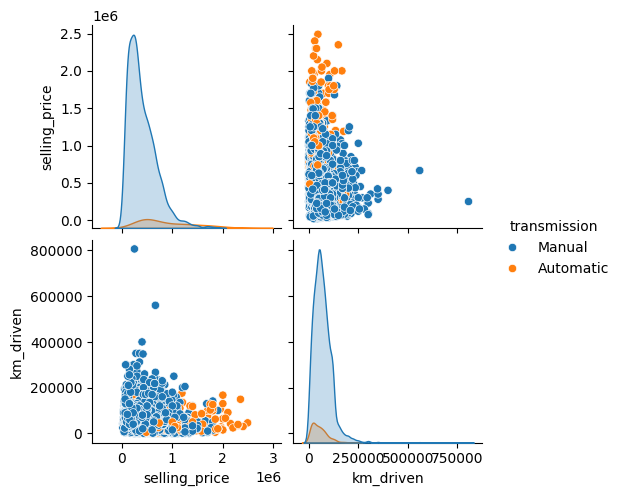

In [247]:

columns_to_plot = ["selling_price","km_driven","fuel","transmission"]

sns.pairplot(car_data_cleaned[columns_to_plot],hue="transmission")
plt.show()

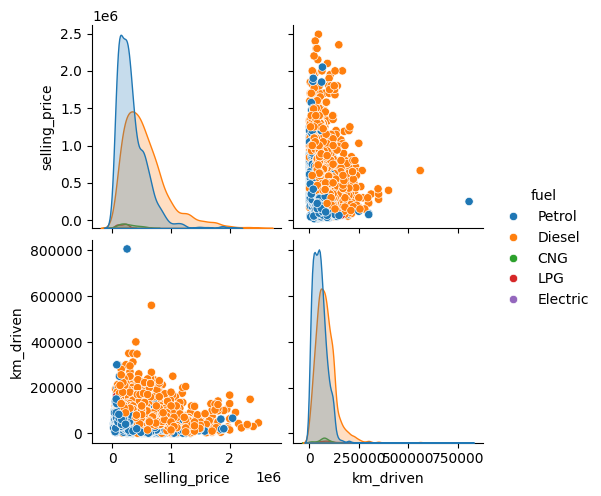

In [248]:

columns_to_plot = ["selling_price","km_driven","fuel","transmission"]

sns.pairplot(car_data_cleaned[columns_to_plot],hue="fuel")
plt.show()

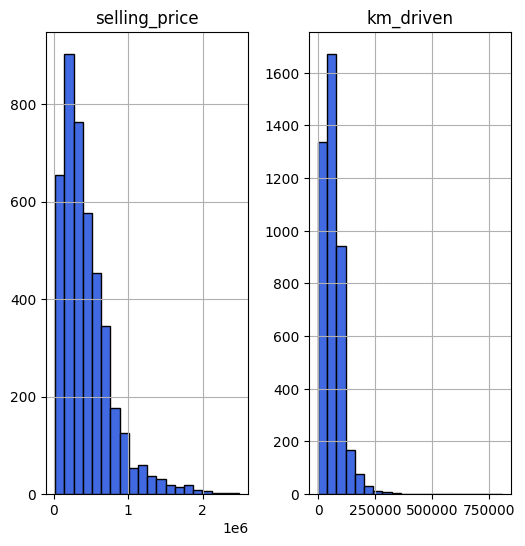

In [249]:

car_data_cleaned[["selling_price","fuel","km_driven","transmission"]].hist(bins=20, figsize=(6,6), color='royalblue', edgecolor='black')
plt.show()


Separating features and labels

In [250]:
x = car_data_encoded.drop(columns="selling_price", axis=1)

print(x)

      km_driven  car_age  fuel_Diesel  fuel_Electric  fuel_LPG  fuel_Petrol  \
0         70000       19            0              0         0            1   
1         50000       19            0              0         0            1   
2        100000       14            1              0         0            0   
3         46000        9            0              0         0            1   
4        141000       12            1              0         0            0   
...         ...      ...          ...            ...       ...          ...   
4335      80000       12            1              0         0            0   
4336      80000       12            1              0         0            0   
4337      83000       17            0              0         0            1   
4338      90000       10            1              0         0            0   
4339      40000       10            0              0         0            1   

      seller_type_Individual  seller_type_Trustmark

In [251]:
y = car_data_encoded["selling_price"]

print(y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4253, dtype: int64


Splitting data into training data and test data

In [252]:
x_train , x_test , y_train , y_test = train_test_split(x ,y , test_size=0.2 , shuffle=True ,random_state=2)

Scaling Training and Testing targets

In [253]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.fit_transform(x_test)


Reshaping into a 2D matrix

In [254]:
y_train_2d = y_train.values.reshape(-1, 1)
y_test_2d = y_test.values.reshape(-1, 1)

In [255]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train_2d)

y_test_scaled = y_scaler.fit_transform(y_test_2d)

In [256]:
print(x_train.shape , x_test.shape)

(3402, 41) (851, 41)


Dropping features that have little to no variation

In [257]:
selector = VarianceThreshold(threshold=0.01)
x_train_scaled = selector.fit_transform(x_train_scaled)
x_test_scaled = selector.transform(x_test_scaled)

Model Training 

In [258]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,  # Slows down learning to prevent noise memorization
    max_depth=5,         # Crucial: standard shallow trees to force generalization
    random_state=42
)

In [259]:
model.fit(x_train_scaled ,y_train_scaled.ravel())

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

Model Evaluation

In [260]:
x_train_prediction = model.predict(x_train_scaled)

In [261]:
error_score = metrics.r2_score(y_train_scaled,x_train_prediction)

print("R Squared Error :",error_score)

R Squared Error : 0.8402585649913927


In [262]:
x_test_prediction = model.predict(x_test_scaled)

In [263]:
error_score_test = metrics.r2_score(y_test_scaled , x_test_prediction)

print("R Squared Error :",error_score_test)

R Squared Error : 0.7855867236896313


Creating a scatter plot for actual vs predicted car prices

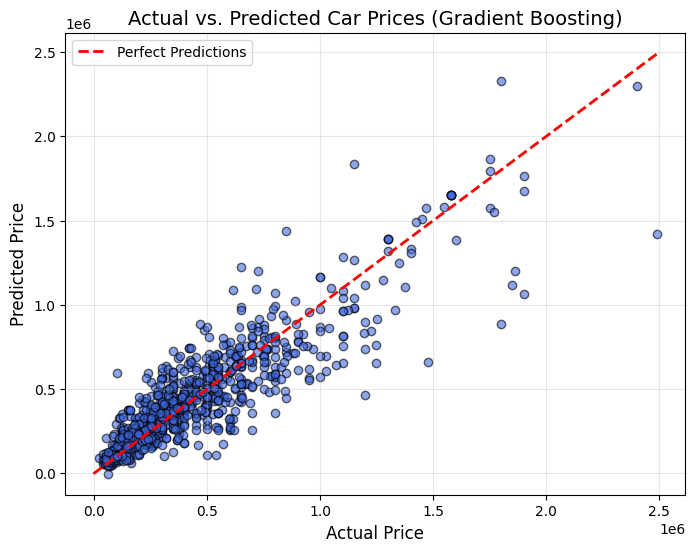

In [264]:
# 1. Inverse transform the scaled test answers and predictions back to original prices
y_test_original = y_scaler.inverse_transform(y_test_scaled)
x_test_prediction_original = y_scaler.inverse_transform(x_test_prediction.reshape(-1, 1))

# 2. Set up the plotting window
plt.figure(figsize=(8, 6))

# 3. Create the scatter plot
plt.scatter(y_test_original, x_test_prediction_original, color='royalblue', alpha=0.6, edgecolors='black')

# 4. Draw a perfect diagonal reference line (If points hit this line, the guess is 100% perfect)
max_val = max(max(y_test_original), max(x_test_prediction_original))
min_val = min(min(y_test_original), min(x_test_prediction_original))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Predictions')

# 5. Labels and styling
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs. Predicted Car Prices (Gradient Boosting)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()